# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [11]:
# wczytanie zbioru danych
titanic = pd.read_csv("sample_data/titanic.csv")

titanic.shape

(891, 12)

In [3]:
# MIEJSCE NA TWÓJ KOD
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Survived - czy dana osoba przeżyła (1 albo 0)

pclass - numer klasy
1 = Wysoka
2 = Średnia
3 = Niska

Age - wiek. Jest ułamkiem kiedy jest < 1. Kiedy wiek jest szacowany ma postać: xx.5

sibsp - liczba rodzeństwa / małżonków na pokładzie.
Rodzeństwo = brat, siostra, brat przyrodni, siostra przyrodnia
Małżonek = mąż, żona (kochanki i narzeczeni zostali pominięci)

parch - liczba rodziców / dzieci na pokładzie.
Rodzic = matka, ojciec
Dziecko = córka, syn, córka przyrodnia, syn przyrodni. Niektóre dzieci podróżowały tylko z nianią, dlatego dla nich parch=0.

Ticket - numer biletu

Fare - ile zapłacił pasażer

Cabin - numer kabiny

Embarked - port zaokrętowania. C = Cherbourg, Q = Queenstown, S = Southampton.

## Przekształcenie danych

In [ ]:
# MIEJSCE NA TWÓJ KOD


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

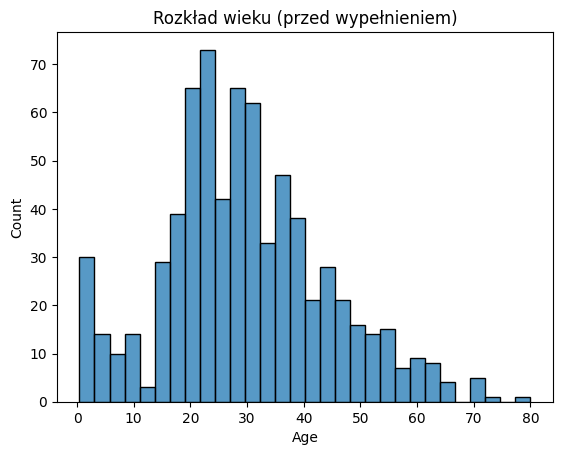

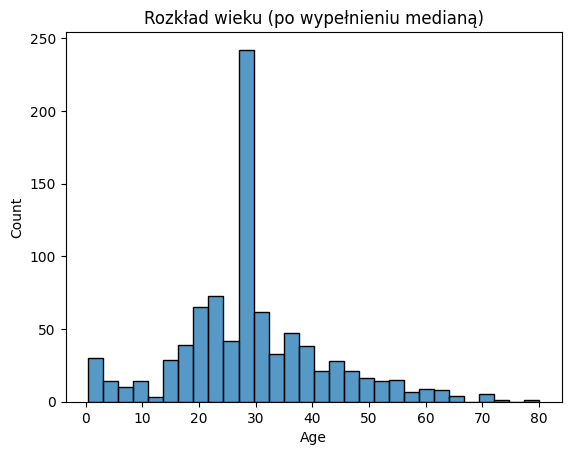

In [4]:
# MIEJSCE NA TWÓJ KOD
sns.histplot(data=titanic, x='Age', bins=30)
plt.title("Rozkład wieku (przed wypełnieniem)")
plt.show()

mediana_wieku = titanic['Age'].median()
titanic['Age'] = titanic['Age'].fillna(mediana_wieku)

sns.histplot(data=titanic, x='Age', bins=30)
plt.title("Rozkład wieku (po wypełnieniu medianą)")
plt.show()

In [8]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [5]:
# MIEJSCE NA TWÓJ KOD
titanic['Embarked'] = titanic['Embarked'].fillna('S')

In [10]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [15]:
# MIEJSCE NA TWÓJ KOD
import random
import string
import re

zuzyte_numery = {litera: set() for litera in string.ascii_uppercase}

for kabina in titanic['Cabin'].dropna():
    znalezione = re.findall(r'([a-zA-Z])(\d+)', str(kabina))
    for litera, liczba_str in znalezione:
        litera_duza = litera.upper()
        liczba = int(liczba_str)
        if litera_duza in zuzyte_numery:
            zuzyte_numery[litera_duza].add(liczba)

def generuj_kabine():
    while True:
        litera = random.choice(string.ascii_uppercase)
        if len(zuzyte_numery[litera]) < 1000:
            break

    while True:
        liczba = random.randint(0, 999)
        if liczba not in zuzyte_numery[litera]:
            zuzyte_numery[litera].add(liczba)
            return f"{litera}{liczba:03d}"

titanic['Cabin'] = titanic['Cabin'].apply(
    lambda x: generuj_kabine() if pd.isna(x) else x
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,X943,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,A750,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,D742,S


In [14]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [10]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

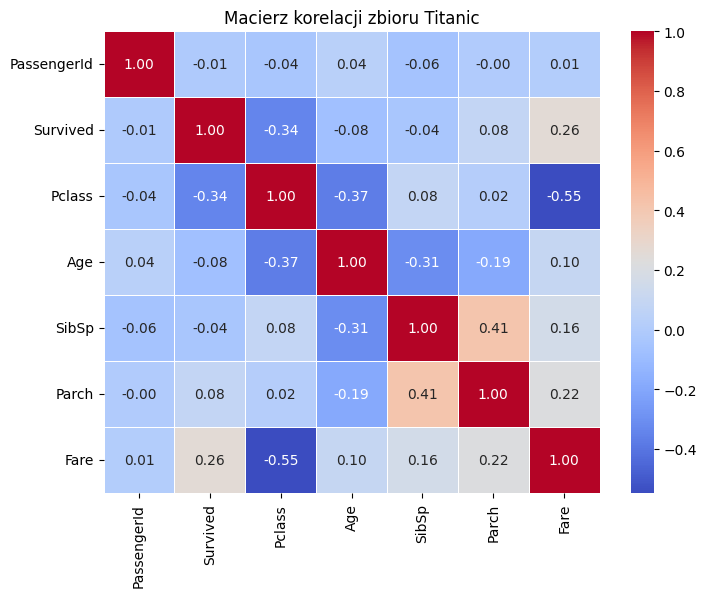

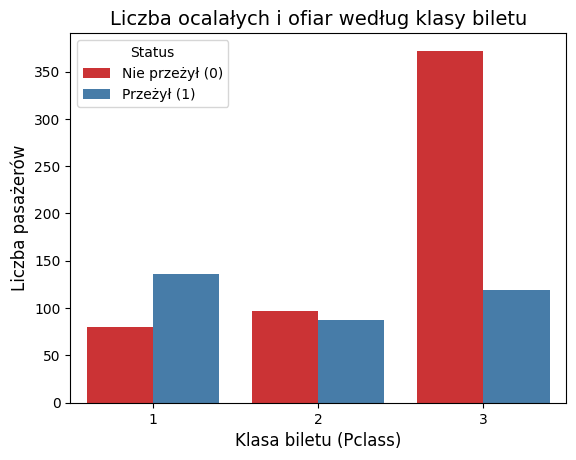

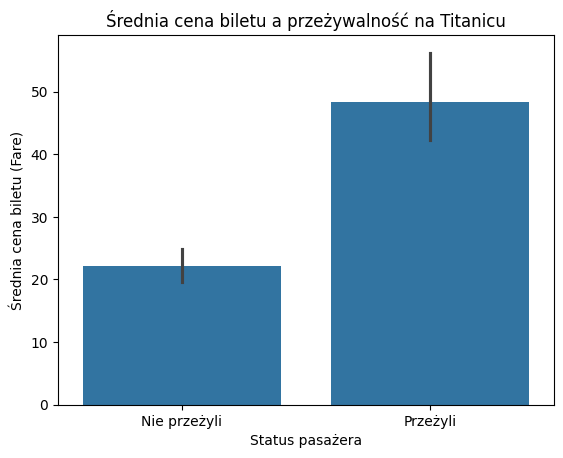

In [24]:
# MIEJSCE NA TWÓJ KOD
macierz_korelacji = titanic.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=macierz_korelacji,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Macierz korelacji zbioru Titanic")
plt.show()

sns.countplot(data=titanic, x='Pclass', hue='Survived', palette='Set1')
plt.title('Liczba ocalałych i ofiar według klasy biletu', fontsize=14)
plt.xlabel('Klasa biletu (Pclass)', fontsize=12)
plt.ylabel('Liczba pasażerów', fontsize=12)
plt.legend(title='Status', labels=['Nie przeżył (0)', 'Przeżył (1)'])
plt.show()

sns.barplot(
    data=titanic,
    x='Survived',
    y='Fare',
    estimator='mean'
)
plt.xticks(ticks=[0, 1], labels=['Nie przeżyli', 'Przeżyli'])
plt.title('Średnia cena biletu a przeżywalność na Titanicu')
plt.xlabel('Status pasażera')
plt.ylabel('Średnia cena biletu (Fare)')
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

/tmp/ipykernel_7858/3591791322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='Pclass', y='Survived', palette='Blues_d', errorbar=None)


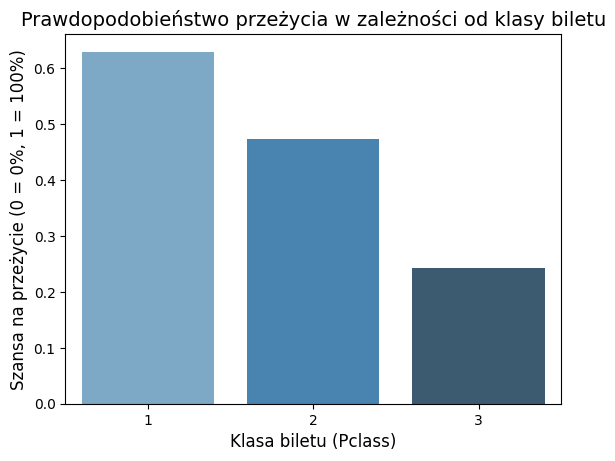

In [15]:
# MIEJSCE NA TWÓJ KOD
sns.barplot(data=titanic, x='Pclass', y='Survived', palette='Blues_d', hue='Pclass', errorbar=None, legend= False)

plt.title('Prawdopodobieństwo przeżycia w zależności od klasy biletu', fontsize=14)
plt.xlabel('Klasa biletu (Pclass)', fontsize=12)
plt.ylabel('Szansa na przeżycie (0 = 0%, 1 = 100%)', fontsize=12)

plt.show()

# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [4]:
spotify = pd.read_csv("sample_data/data.csv")

spotify.shape

(114000, 21)

In [17]:
# MIEJSCE NA TWÓJ KOD
spotify.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


track_id - Identyfikator utworu w Spotify

artists - Nazwy wykonawców, którzy wykonali utwór. Jeśli jest więcej niż jeden wykonawca, są oni oddzieleni znakiem ;

album_name - Nazwa albumu, na którym znajduje się utwór

track_name - Nazwa utworu

popularity - Popularność utworu to wartość od 0 do 100, gdzie 100 oznacza największą popularność. Popularność jest obliczana przez algorytm i opiera się w głównej mierze na całkowitej liczbie odtworzeń utworu oraz na tym, jak niedawne są to odtworzenia. Ogólnie rzecz biorąc, piosenki, które są obecnie często odtwarzane, będą miały wyższą popularność niż piosenki, które były często odtwarzane w przeszłości. Zduplikowane utwory (np. ten sam utwór z singla i z albumu) są oceniane niezależnie. Popularność artysty i albumu jest matematycznie wywodzona z popularności utworu.

duration_ms - Długość utworu w milisekundach

explicit - Określa, czy utwór zawiera niecenzuralne teksty (true = tak, zawiera; false = nie, nie zawiera LUB nieznane)

danceability - Taneczność określa, jak bardzo utwór nadaje się do tańca w oparciu o połączenie elementów muzycznych, w tym tempa, stabilności rytmu, siły beatu i ogólnej regularności. Wartość 0.0 oznacza utwór najmniej taneczny, a 1.0 najbardziej taneczny

energy - Energia to miara od 0.0 do 1.0, stanowiąca percepcyjną miarę intensywności i aktywności. Zazwyczaj energiczne utwory wydają się szybkie, głośne i hałaśliwe. Na przykład death metal ma wysoką energię, podczas gdy preludium Bacha uzyskuje niski wynik na tej skali

key - Tonacja, w której utrzymany jest utwór. Liczby całkowite odpowiadają wysokościom dźwięków przy użyciu standardowej notacji klas wysokości dźwięku (Pitch Class). Np. 0 = C, 1 = C♯/D♭, 2 = D i tak dalej. Jeśli nie wykryto tonacji, wartość wynosi -1
loudness - Ogólna głośność utworu w decybelach (dB)

mode - Tryb wskazuje na modalność (dur lub moll) utworu, czyli rodzaj skali, z której wywodzi się jego zawartość melodyczna. Tryb durowy (major) jest reprezentowany przez 1, a mollowy (minor) przez 0

speechiness - Mowa (speechiness) wykrywa obecność słów mówionych w utworze. Im bardziej nagranie przypomina mowę (np. talk-show, audiobook, poezja), tym wartość atrybutu jest bliższa 1.0. Wartości powyżej 0.66 opisują utwory, które prawdopodobnie składają się w całości z mówionych słów. Wartości pomiędzy 0.33 a 0.66 opisują utwory, które mogą zawierać zarówno muzykę, jak i mowę, w sekcjach lub nakładające się na siebie, włączając w to takie przypadki jak rap. Wartości poniżej 0.33 najprawdopodobniej reprezentują muzykę i inne utwory nieprzypominające mowy

acousticness - Miara pewności od 0.0 do 1.0 określająca, czy utwór jest akustyczny. 1.0 oznacza wysoką pewność, że utwór jest akustyczny

instrumentalness - Przewiduje, czy utwór nie zawiera wokalu. Dźwięki "Ooh" i "aah" są w tym kontekście traktowane jako instrumentalne. Utwory rapowe lub słowo mówione są wyraźnie "wokalne". Im wartość instrumentalności jest bliższa 1.0, tym większe prawdopodobieństwo, że utwór nie zawiera treści wokalnych

liveness - Wykrywa obecność publiczności w nagraniu. Wyższe wartości liveness oznaczają zwiększone prawdopodobieństwo, że utwór był wykonywany na żywo. Wartość powyżej 0.8 daje duże prawdopodobieństwo, że utwór jest nagraniem z koncertu

valence - Miara od 0.0 do 1.0 opisująca muzyczną pozytywność (walencję) przekazywaną przez utwór. Utwory o wysokiej walencji brzmią bardziej pozytywnie (np. radośnie, wesoło, euforycznie), podczas gdy utwory o niskiej walencji brzmią bardziej negatywnie (np. smutnie, depresyjnie, gniewnie)

tempo - Ogólne szacowane tempo utworu w uderzeniach na minutę (BPM). W terminologii muzycznej tempo to prędkość lub miarowość danego utworu i wywodzi się bezpośrednio ze średniego czasu trwania uderzenia

time_signature - Szacowane metrum. Metrum to konwencja notacyjna określająca, ile uderzeń znajduje się w każdym takcie. Wartość metrum waha się od 3 do 7, co oznacza metrum od 3/4 do 7/4.

track_genre - Gatunek, do którego należy utwór

## Przekształcenia i filtracja danych

In [ ]:
# MIEJSCE NA TWÓJ KOD

## Wizualizacje

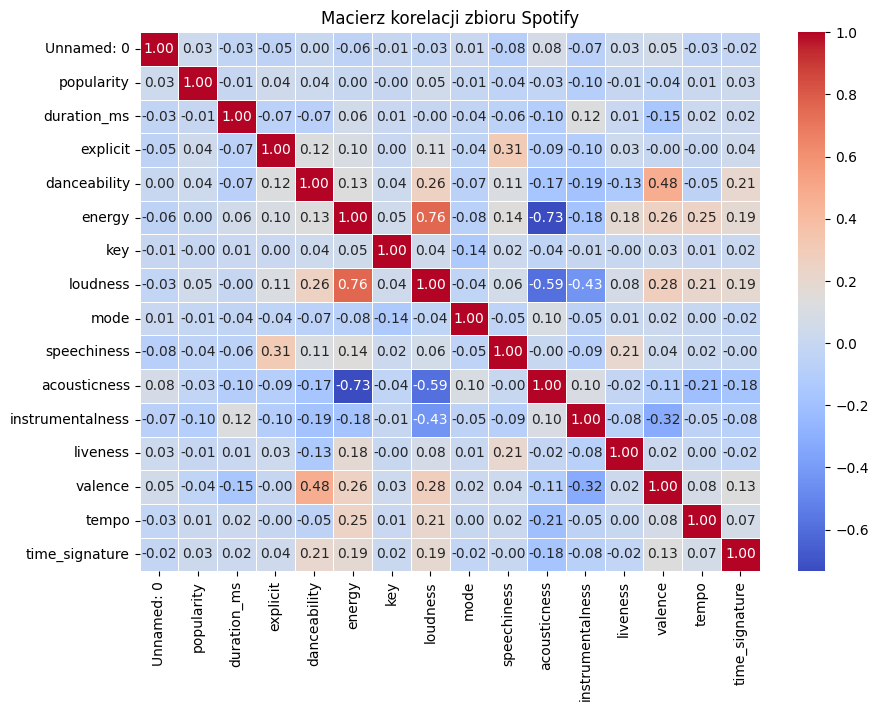

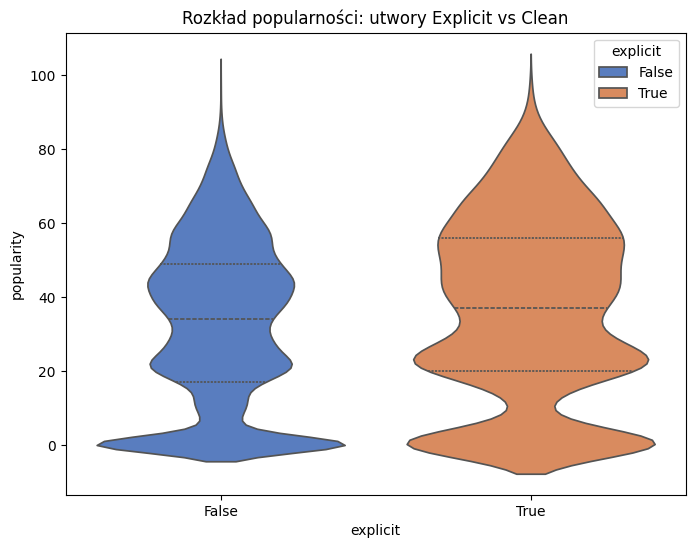

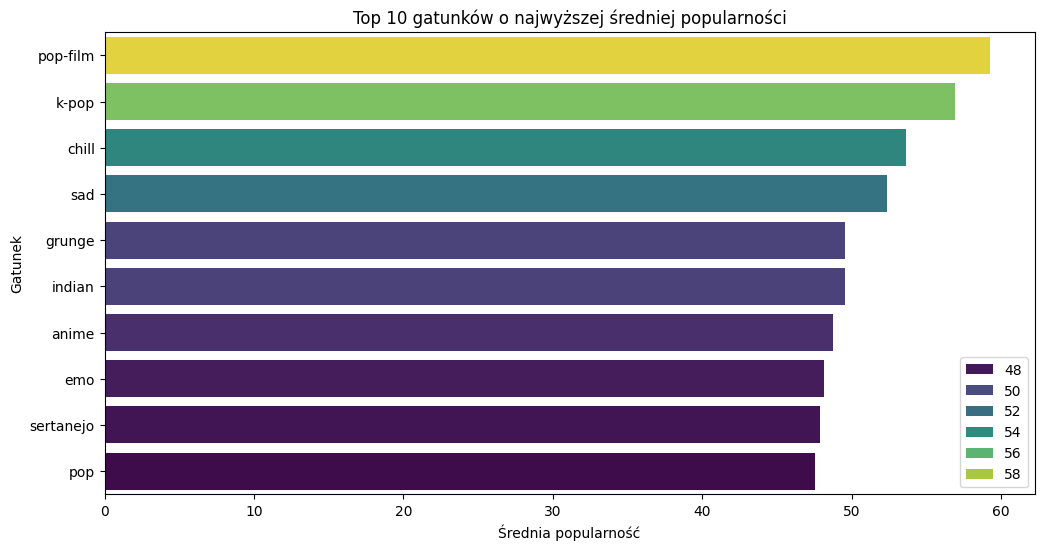

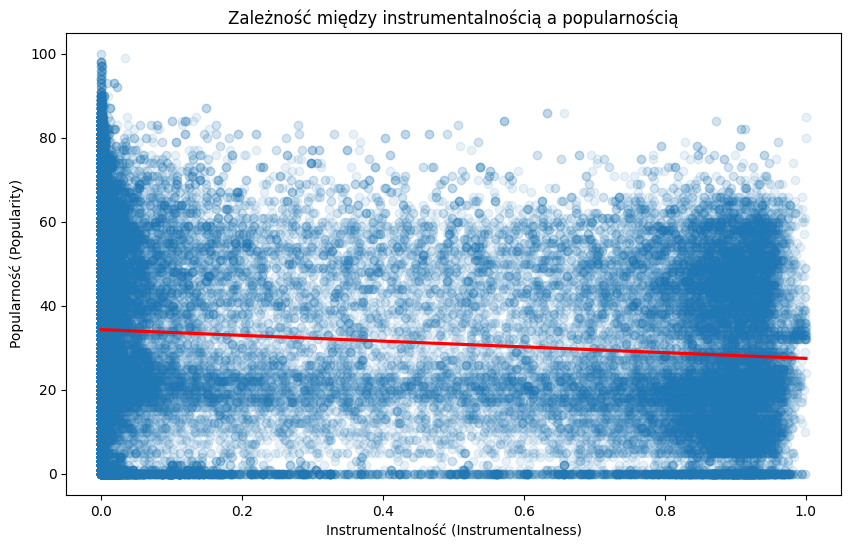

In [10]:
# MIEJSCE NA TWÓJ KOD
macierz_korelacji = spotify.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(
    data=macierz_korelacji,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Macierz korelacji zbioru Spotify")
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=spotify,
    x='explicit',
    y='popularity',
    palette='muted',
    hue='explicit',
    inner='quartile'
)
plt.title("Rozkład popularności: utwory Explicit vs Clean")
plt.show()

plt.figure(figsize=(12, 6))
top_genres = spotify.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='viridis',
    hue=top_genres.values
)
plt.title("Top 10 gatunków o najwyższej średniej popularności")
plt.xlabel("Średnia popularność")
plt.ylabel("Gatunek")
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=spotify,
    x='instrumentalness',
    y='popularity',
    scatter_kws={'alpha': 0.1},
    line_kws={'color': 'red'}   # Linia trendu
)
plt.title("Zależność między instrumentalnością a popularnością")
plt.xlabel("Instrumentalność (Instrumentalness)")
plt.ylabel("Popularność (Popularity)")
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [11]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [12]:
emocje = []
for k, m in zip(spotify['key'], spotify['mode']):
    nazwa_tonacji = key_map.get(k)
    if m == 1:
        nazwa_trybu = 'Major'
    else:
        nazwa_trybu = 'Minor'
    para_muzyczna = (nazwa_tonacji, nazwa_trybu)
    odgadnieta_emocja = emotion_map.get(para_muzyczna, 'Unknown')
    emocje.append(odgadnieta_emocja)

spotify['emotion'] = emocje

## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [13]:
# MIEJSCE NA TWÓJ KOD
my_feats = [
    'artists',
    'popularity',
    'duration_ms',
    'explicit',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature',
    'track_genre',
    'emotion'
]
spotify.filter(items=my_feats)

,artists,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,emotion
0,Gen Hoshino,73,230666,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,Melancholic
1,Ben Woodward,55,149610,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,Joyful
2,Ingrid Michaelson;ZAYN,57,210826,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,Happy
3,Kina Grannis,71,201933,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,Happy
4,Chord Overstreet,82,198853,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,Triumphant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,21,384999,False,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,Passionate
113996,Rainy Lullaby,22,385000,False,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,Sad
113997,Cesária Evora,22,271466,False,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,Sad
113998,Michael W. Smith,41,283893,False,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,Rustic


### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [18]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
example_feats = ["duration_ms", "explicit", "danceability", "energy","key", "loudness", "mode", "speechiness", "acousticness","instrumentalness", "liveness", "valence", "tempo", "time_signature"]

base_acc = classify(spotify, example_feats)


test_feats = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

base_acc = classify(spotify, test_feats)



Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Test Acc  : 0.6214
Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6074


### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [15]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest

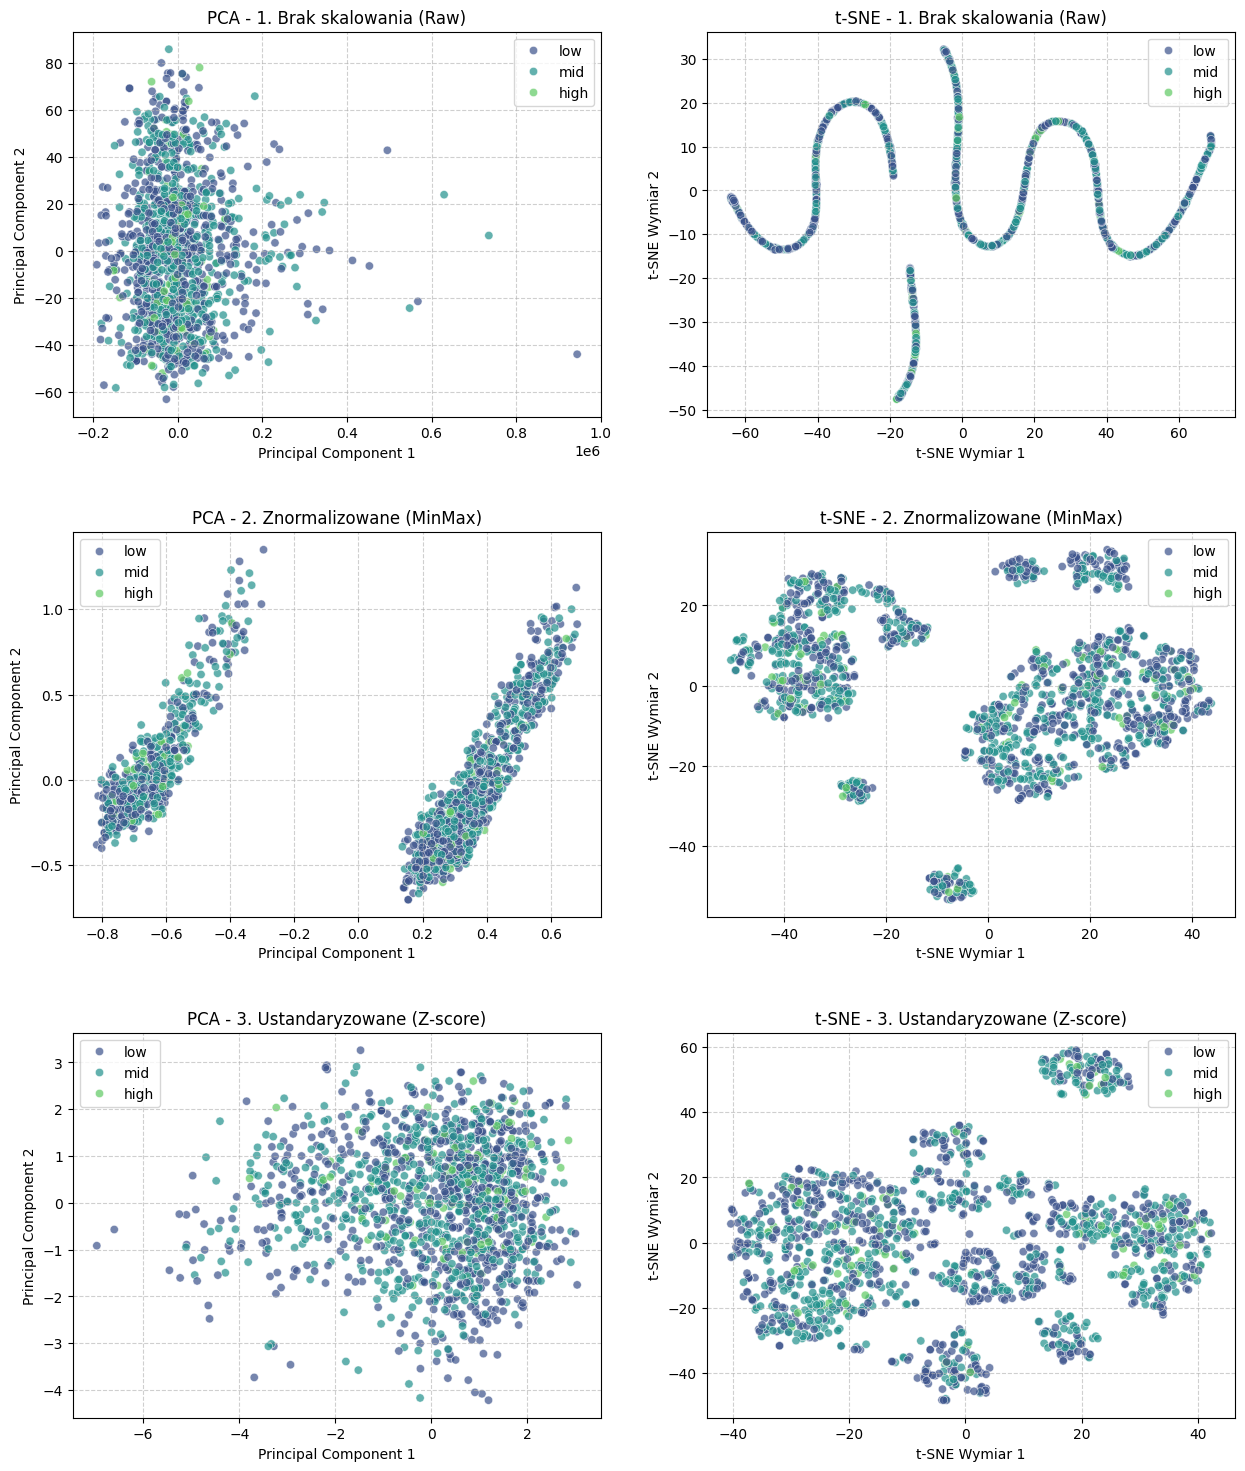

In [20]:
# przykładowe funkcje

def dataframe_xy(df):
    df_temp = df.copy()
    if 'popularity_bracket' not in df_temp.columns:
        df_temp["popularity_bracket"] = pd.cut(df_temp["popularity"], bins=[-1, 33, 66, 100], labels=["low", "mid", "high"])
    df_temp = df_temp.dropna(subset=example_feats + ["popularity_bracket"])

    df_sampled = df_temp.sample(1500, random_state=42)

    X = df_sampled[example_feats].values
    y = df_sampled['popularity_bracket'].values
    return X, y

# Normalizacja do zakresu [0,1]
def normalize(X):
    scaler = MinMaxScaler()
    return scaler.fit_transform(X)

# Standaryzacja (średnia 0, odchylenie standardowe 1)
def standarize(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

# Usuwanie wartości odstających (Outliers)
def remove_outliers(X, y):
    iso = IsolationForest(contamination=0.05, random_state=42)
    yhat = iso.fit_predict(X)

    mask = (yhat != -1) # zachowujemy tylko to, co nie jest anomalią (-1)
    return X[mask], y[mask]


X_raw, y_raw = dataframe_xy(spotify)

X_clean, y_clean = remove_outliers(X_raw, y_raw)

dane_do_testow = {
    "1. Brak skalowania (Raw)": X_clean,
    "2. Znormalizowane (MinMax)": normalize(X_clean),
    "3. Ustandaryzowane (Z-score)": standarize(X_clean)
}

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.3)

for idx, (tytul, X_wersja) in enumerate(dane_do_testow.items()):

    # PCA (Redukcja do 2 wymiarów)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_wersja)

    # t-SNE (Redukcja do 2 wymiarów)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne = tsne.fit_transform(X_wersja)

    # Rysowanie PCA
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_clean, palette='viridis', alpha=0.7, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"PCA - {tytul}")
    axes[idx, 0].set_xlabel("Principal Component 1")
    axes[idx, 0].set_ylabel("Principal Component 2")
    axes[idx, 0].grid(True, linestyle='--', alpha=0.6)

    # Rysowanie t-SNE
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y_clean, palette='viridis', alpha=0.7, ax=axes[idx, 1])
    axes[idx, 1].set_title(f"t-SNE - {tytul}")
    axes[idx, 1].set_xlabel("t-SNE Wymiar 1")
    axes[idx, 1].set_ylabel("t-SNE Wymiar 2")
    axes[idx, 1].grid(True, linestyle='--', alpha=0.6)

plt.show()
